# Network Intrusion Detection System
## NSL-KDD Dataset | SVM · XGBoost · Random Forest · Voting Ensemble
---
**Pipeline:**
1. Data Loading & EDA
2. Preprocessing (Encoding, SMOTE, Scaling, Feature Selection)
3. SVM — Training, Evaluation, Visualizations
4. XGBoost — Training, Evaluation, Visualizations
5. Random Forest — Training, Evaluation, Visualizations
6. Weighted Soft Voting Ensemble
7. Ensemble Evaluation & Visualizations
8. Cross-Model Comparison Summary


In [1]:
import os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_curve, auc
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
LABELS = ['dos', 'normal', 'probe', 'r2l', 'u2r']
N_CLASS = 5
print('All imports successful.')


All imports successful.


---
## Part 1 · Data Loading & Exploration


In [2]:
# ── PATHS (edit DATA_DIR to match your machine) ──────────────────
DATA_DIR   = r'C:\Users\dmacs-234204\Desktop\intrusion_detection\datasets'
TRAIN_FILE = os.path.join(DATA_DIR, 'KDDTrain+.txt')
TEST_FILE  = os.path.join(DATA_DIR, 'KDDTest+.txt')
MODELS_DIR = r'C:\Users\dmacs-234204\Desktop\intrusion_detection\models'
os.makedirs(MODELS_DIR, exist_ok=True)

COL_NAMES = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login','is_guest_login',
    'count','srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'label','difficulty'
]

ATTACK_MAP = {
    'normal':'normal',
    'neptune':'dos','smurf':'dos','back':'dos','teardrop':'dos','pod':'dos','land':'dos',
    'portsweep':'probe','ipsweep':'probe','nmap':'probe','satan':'probe',
    'guess_passwd':'r2l','ftp_write':'r2l','imap':'r2l','phf':'r2l','multihop':'r2l',
    'warezmaster':'r2l','warezclient':'r2l','spy':'r2l',
    'buffer_overflow':'u2r','rootkit':'u2r','loadmodule':'u2r','perl':'u2r'
}

df_train = pd.read_csv(TRAIN_FILE, names=COL_NAMES)
df_test  = pd.read_csv(TEST_FILE,  names=COL_NAMES)
df_train['attack_category'] = df_train['label'].map(ATTACK_MAP)
df_test['attack_category']  = df_test['label'].map(ATTACK_MAP)
df_train = df_train.dropna(subset=['attack_category'])
df_test  = df_test.dropna(subset=['attack_category'])

print(f'Train: {df_train.shape}  |  Test: {df_test.shape}')
print('\nTrain Class Distribution:')
print(df_train['attack_category'].value_counts())
print('\nTest Class Distribution:')
print(df_test['attack_category'].value_counts())
df_train.head(3)


Train: (125973, 44)  |  Test: (18794, 44)

Train Class Distribution:
attack_category
normal    67343
dos       45927
probe     11656
r2l         995
u2r          52
Name: count, dtype: int64

Test Class Distribution:
attack_category
normal    9711
dos       5741
r2l       2199
probe     1106
u2r         37
Name: count, dtype: int64


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty,attack_category
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal,20,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal,15,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.0,1.0,1.0,0.00,0.0,neptune,19,dos


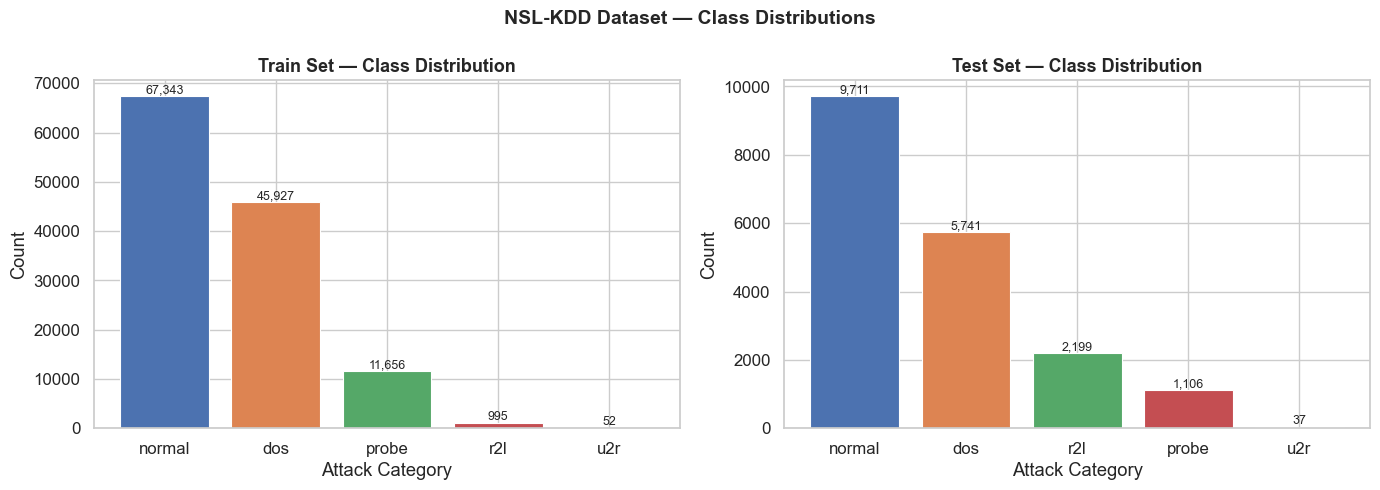

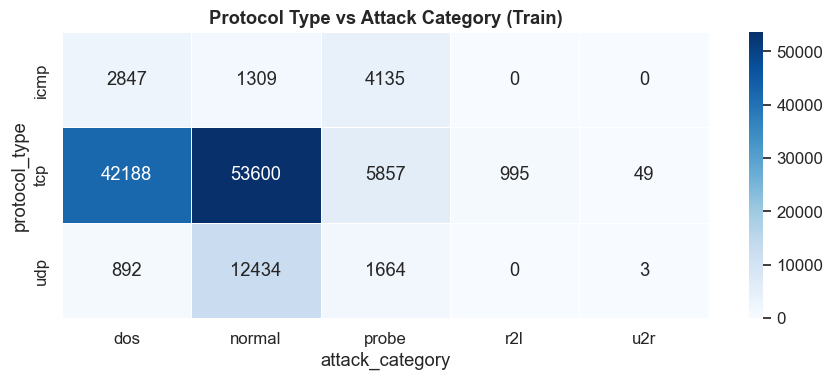

In [3]:
# ── EDA: Class distribution & protocol breakdown ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in zip(axes,
                          [df_train, df_test],
                          ['Train Set', 'Test Set']):
    counts = df['attack_category'].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=COLORS[:len(counts)], edgecolor='white', linewidth=0.8)
    ax.set_title(f'{title} — Class Distribution', fontweight='bold', fontsize=13)
    ax.set_xlabel('Attack Category'); ax.set_ylabel('Count')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, v + counts.max()*0.01,
                f'{v:,}', ha='center', fontsize=9)

plt.suptitle('NSL-KDD Dataset — Class Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'eda_class_dist.png'), dpi=150, bbox_inches='tight')
plt.show()

# Protocol × attack heatmap
pivot = df_train.groupby(['protocol_type','attack_category']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title('Protocol Type vs Attack Category (Train)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'eda_protocol_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## Part 2 · Preprocessing


In [4]:
# ── 2A: Label encode categorical cols ────────────────────────────
CAT_COLS = ['protocol_type', 'service', 'flag']
label_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df_train[col] = le.fit_transform(df_train[col])
    df_test[col]  = le.transform(df_test[col])
    label_encoders[col] = le

df_train = df_train.drop(columns=['label','difficulty'])
df_test  = df_test.drop(columns=['label','difficulty'])
print('Categorical encoding done.')
df_train.head(3)


Categorical encoding done.


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_category
0,0,1,20,9,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal
1,0,2,44,9,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal
2,0,1,49,5,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,dos


In [5]:
# ── 2B: Downsample majority + SMOTE for minority ─────────────────
TARGET = 10_000
dfs = []
for cls, cnt in df_train['attack_category'].value_counts().items():
    df_cls = df_train[df_train.attack_category == cls]
    dfs.append(df_cls.sample(min(cnt, TARGET), random_state=42))
df_balanced = pd.concat(dfs)

LABEL_MAP     = {c: i for i, c in enumerate(sorted(df_balanced['attack_category'].unique()))}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}
print('Label map:', LABEL_MAP)

df_balanced['attack_category'] = df_balanced['attack_category'].map(LABEL_MAP)
df_test['attack_category']     = df_test['attack_category'].map(LABEL_MAP)

X_bal = df_balanced.drop(columns=['attack_category'])
y_bal = df_balanced['attack_category']

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_bal, y_bal)
print(f'After SMOTE: {X_train_sm.shape[0]} samples')
print(pd.Series(y_train_sm).value_counts().rename(INV_LABEL_MAP))


Label map: {'dos': 0, 'normal': 1, 'probe': 2, 'r2l': 3, 'u2r': 4}
After SMOTE: 50000 samples
attack_category
normal    10000
dos       10000
probe     10000
r2l       10000
u2r       10000
Name: count, dtype: int64


In [6]:
# ── 2C: StandardScaler + SelectKBest (k=35) ──────────────────────
X_test_raw = df_test.drop(columns=['attack_category'])
y_test     = df_test['attack_category']

scaler   = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test_raw)

selector = SelectKBest(score_func=f_classif, k=35)
X_train_sel = selector.fit_transform(X_train_scaled, y_train_sm)
X_test_sel  = selector.transform(X_test_scaled)

print(f'Train: {X_train_sel.shape}  |  Test: {X_test_sel.shape}')

joblib.dump(scaler,         os.path.join(MODELS_DIR, 'scaler.pkl'))
joblib.dump(selector,       os.path.join(MODELS_DIR, 'selector.pkl'))
joblib.dump(label_encoders, os.path.join(MODELS_DIR, 'label_encoders.pkl'))
joblib.dump(LABEL_MAP,      os.path.join(MODELS_DIR, 'label_map.pkl'))
print('Preprocessing artifacts saved.')


Train: (50000, 35)  |  Test: (18794, 35)
Preprocessing artifacts saved.


---
## Part 3 · Model Training & Evaluation


In [7]:
# ── Helper: full evaluation + 3-panel visualization ──────────────
ALL_FEATURE_NAMES = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login','is_guest_login',
    'count','srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate'
]

def evaluate_model(name, y_true, y_pred, y_prob=None):
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)

    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Macro F1  : {f1:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'{chr(45)*55}')
    print(classification_report(y_true, y_pred, target_names=LABELS, zero_division=0))

    fig = plt.figure(figsize=(18, 5))
    gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.4)

    # Confusion matrix
    ax1 = fig.add_subplot(gs[0])
    cm  = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=LABELS, yticklabels=LABELS,
                linewidths=0.5, ax=ax1, cbar_kws={'shrink':0.8})
    ax1.set_title(f'{name}\nNormalized Confusion Matrix', fontweight='bold')
    ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')

    # Per-class F1 bar
    ax2 = fig.add_subplot(gs[1])
    report = classification_report(y_true, y_pred, target_names=LABELS,
                                    output_dict=True, zero_division=0)
    f1s  = [report[l]['f1-score'] for l in LABELS]
    bars = ax2.barh(LABELS, f1s, color=COLORS, edgecolor='white', height=0.6)
    for bar, v in zip(bars, f1s):
        ax2.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                 f'{v:.3f}', va='center', fontsize=10)
    ax2.set_xlim(0, 1.15)
    ax2.set_title(f'{name}\nPer-Class F1 Score', fontweight='bold')
    ax2.set_xlabel('F1 Score')
    ax2.axvline(1.0, color='gray', linestyle='--', linewidth=0.8)

    # ROC curves
    ax3 = fig.add_subplot(gs[2])
    if y_prob is not None:
        y_bin = label_binarize(y_true, classes=list(range(N_CLASS)))
        for i, (lbl, col) in enumerate(zip(LABELS, COLORS)):
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
            ax3.plot(fpr, tpr, color=col, lw=1.8,
                     label=f'{lbl} (AUC={auc(fpr,tpr):.2f})')
        ax3.plot([0,1],[0,1],'k--',lw=1)
        ax3.set_xlim([0,1]); ax3.set_ylim([0,1.02])
        ax3.set_title(f'{name}\nROC Curves (OvR)', fontweight='bold')
        ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
        ax3.legend(fontsize=8, loc='lower right')
    else:
        ax3.text(0.5,0.5,'ROC not available', ha='center', va='center',
                 fontsize=12, color='gray')
        ax3.set_title(f'{name}\nROC Curves', fontweight='bold')

    plt.suptitle(f'{name} — Evaluation Summary', fontsize=14, fontweight='bold', y=1.02)
    fname = name.lower().replace(' ','_').replace('(','').replace(')','').replace('/','_')
    plt.savefig(os.path.join(MODELS_DIR, f'{fname}_evaluation.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    return {'model': name, 'accuracy': acc, 'macro_f1': f1,
            'precision': prec, 'recall': rec}

print('Evaluation helper defined.')


Evaluation helper defined.


---
### 3A · Support Vector Machine (SVM — RBF Kernel)


In [8]:
# ── Train SVM ────────────────────────────────────────────────────
# SVM is trained on a 20k subsample for tractable runtime.
np.random.seed(42)
idx = np.random.choice(len(X_train_sel), size=20_000, replace=False)
X_svm = X_train_sel[idx]
y_svm = np.array(y_train_sm)[idx]

print('Training SVM (RBF, C=10) on 20k samples...')
svm_model = SVC(
    kernel='rbf', C=10, gamma='scale',
    decision_function_shape='ovr',
    probability=True, random_state=42
)
svm_model.fit(X_svm, y_svm)
print('SVM training complete.')
joblib.dump(svm_model, os.path.join(MODELS_DIR, 'svm_model.pkl'))
print('SVM model saved.')


Training SVM (RBF, C=10) on 20k samples...
SVM training complete.
SVM model saved.



  SVM (RBF)
  Accuracy  : 0.8660
  Macro F1  : 0.6201
  Precision : 0.7243
  Recall    : 0.6441
-------------------------------------------------------
              precision    recall  f1-score   support

         dos       0.99      0.99      0.99      5741
      normal       0.82      0.96      0.89      9711
       probe       0.76      0.77      0.77      1106
         r2l       0.94      0.17      0.29      2199
         u2r       0.11      0.32      0.17        37

    accuracy                           0.87     18794
   macro avg       0.72      0.64      0.62     18794
weighted avg       0.88      0.87      0.84     18794



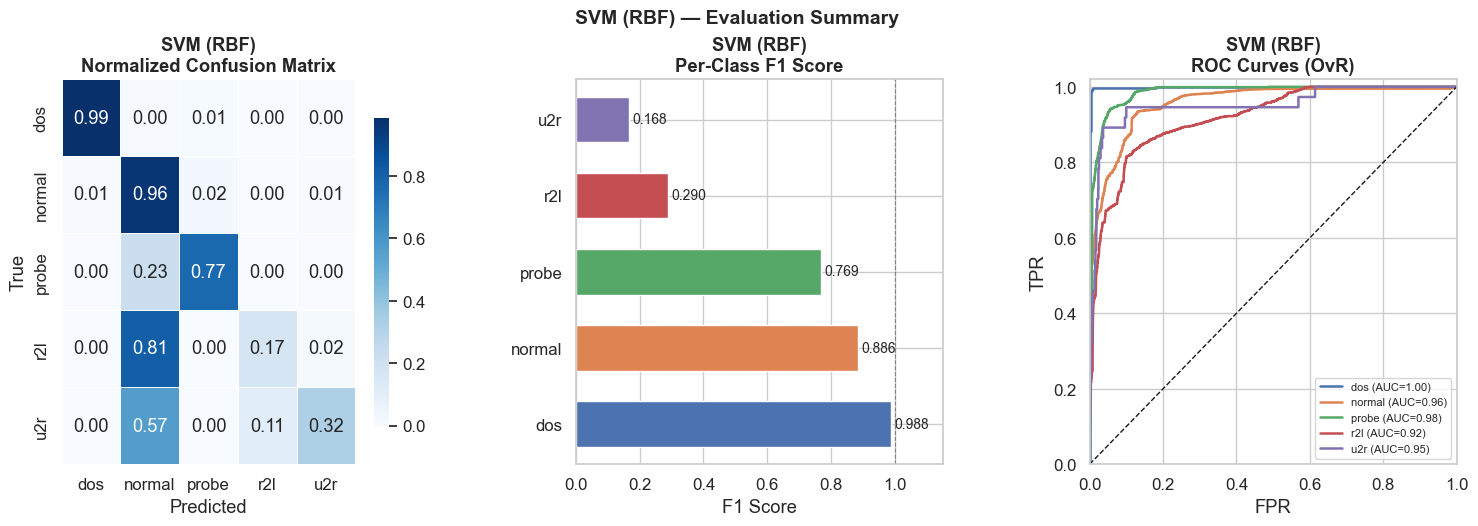

In [9]:
# ── Evaluate SVM ─────────────────────────────────────────────────
y_pred_svm = svm_model.predict(X_test_sel)
y_prob_svm = svm_model.predict_proba(X_test_sel)
svm_metrics = evaluate_model('SVM (RBF)', y_test, y_pred_svm, y_prob_svm)


---
### 3B · XGBoost


In [10]:
# ── Train XGBoost ────────────────────────────────────────────────
print('Training XGBoost...')
xgb_model = XGBClassifier(
    n_estimators=400, learning_rate=0.07, max_depth=9,
    subsample=0.9, colsample_bytree=0.8,
    reg_lambda=1.0, reg_alpha=0.3,
    tree_method='hist',
    objective='multi:softprob', num_class=N_CLASS,
    eval_metric='mlogloss', n_jobs=-1, random_state=42
)
xgb_model.fit(X_train_sel, y_train_sm)
print('XGBoost training complete.')
joblib.dump(xgb_model, os.path.join(MODELS_DIR, 'xgb_model.pkl'))
print('XGBoost model saved.')


Training XGBoost...
XGBoost training complete.
XGBoost model saved.



  XGBoost
  Accuracy  : 0.8984
  Macro F1  : 0.7093
  Precision : 0.7880
  Recall    : 0.7075
-------------------------------------------------------
              precision    recall  f1-score   support

         dos       0.99      0.99      0.99      5741
      normal       0.86      0.97      0.91      9711
       probe       0.80      1.00      0.89      1106
         r2l       0.99      0.31      0.47      2199
         u2r       0.30      0.27      0.29        37

    accuracy                           0.90     18794
   macro avg       0.79      0.71      0.71     18794
weighted avg       0.91      0.90      0.88     18794



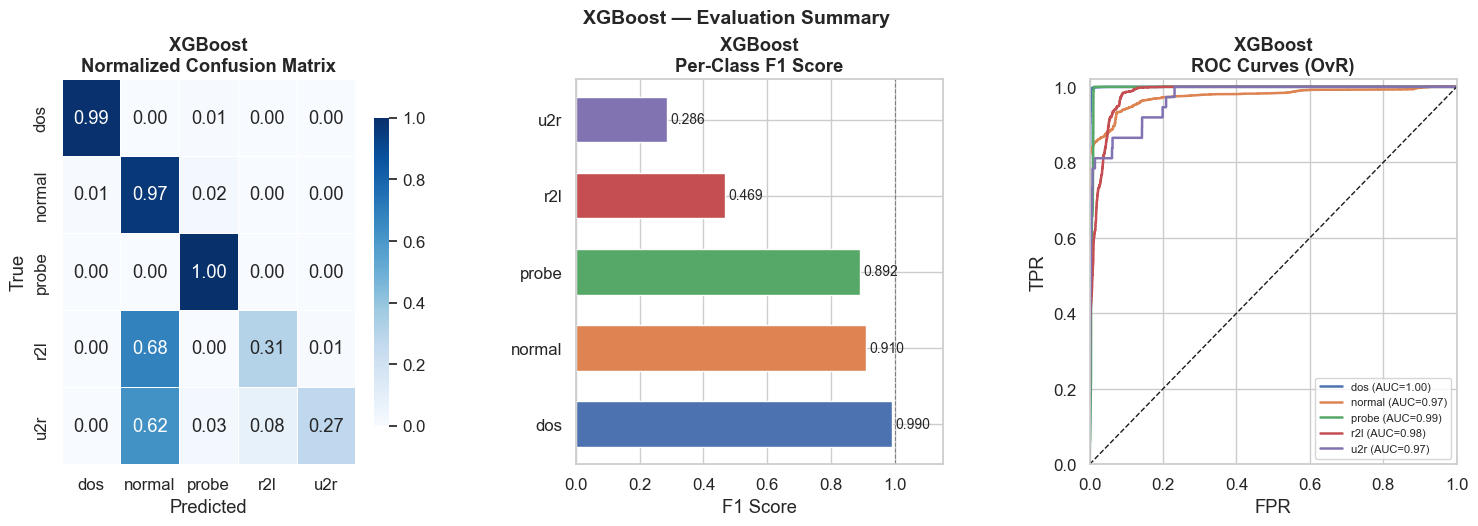

In [11]:
# ── Evaluate XGBoost ──────────────────────────────────────────────
y_pred_xgb = xgb_model.predict(X_test_sel)
y_prob_xgb = xgb_model.predict_proba(X_test_sel)
xgb_metrics = evaluate_model('XGBoost', y_test, y_pred_xgb, y_prob_xgb)


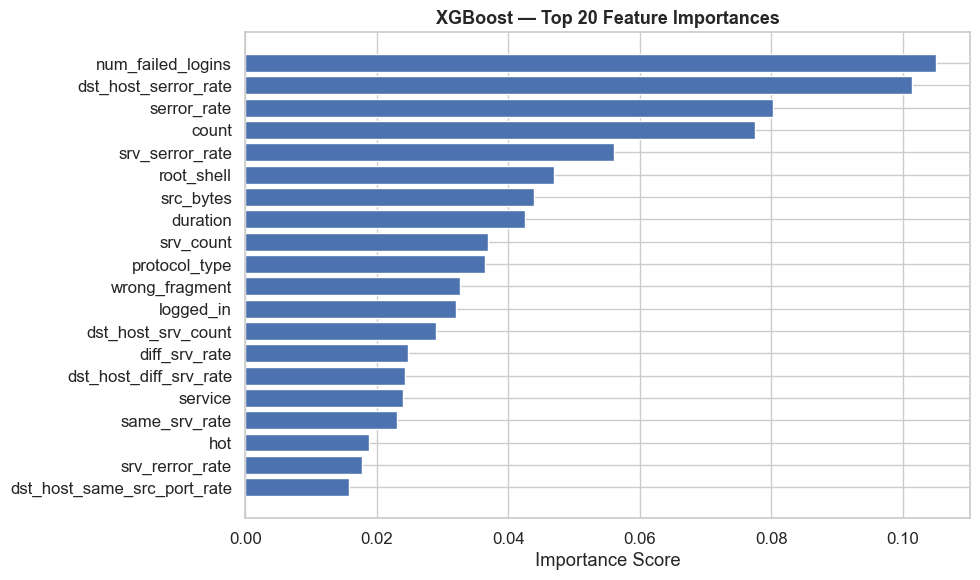

In [12]:
# ── XGBoost Feature Importance (Top 20) ──────────────────────────
selected_mask  = selector.get_support()
selected_names = [f for f, m in zip(ALL_FEATURE_NAMES, selected_mask) if m]

importances = xgb_model.feature_importances_
top_idx     = np.argsort(importances)[-20:]  # ascending

fig, ax = plt.subplots(figsize=(10, 6))
feat_labels = [selected_names[i] if i < len(selected_names) else f'F{i}' for i in top_idx]
ax.barh(feat_labels, importances[top_idx], color='#4C72B0', edgecolor='white')
ax.set_title('XGBoost — Top 20 Feature Importances', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'xgb_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()


---
### 3C · Random Forest


In [13]:
# ── Train Random Forest ───────────────────────────────────────────
print('Training Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=20,
    min_samples_split=5, min_samples_leaf=2,
    max_features='sqrt', class_weight='balanced',
    n_jobs=-1, random_state=42
)
rf_model.fit(X_train_sel, y_train_sm)
print('Random Forest training complete.')
joblib.dump(rf_model, os.path.join(MODELS_DIR, 'rf_model.pkl'))
print('Random Forest model saved.')


Training Random Forest...
Random Forest training complete.
Random Forest model saved.



  Random Forest
  Accuracy  : 0.8785
  Macro F1  : 0.6711
  Precision : 0.7895
  Recall    : 0.6807
-------------------------------------------------------
              precision    recall  f1-score   support

         dos       0.99      0.98      0.99      5741
      normal       0.83      0.97      0.90      9711
       probe       0.79      1.00      0.88      1106
         r2l       0.97      0.15      0.27      2199
         u2r       0.37      0.30      0.33        37

    accuracy                           0.88     18794
   macro avg       0.79      0.68      0.67     18794
weighted avg       0.89      0.88      0.85     18794



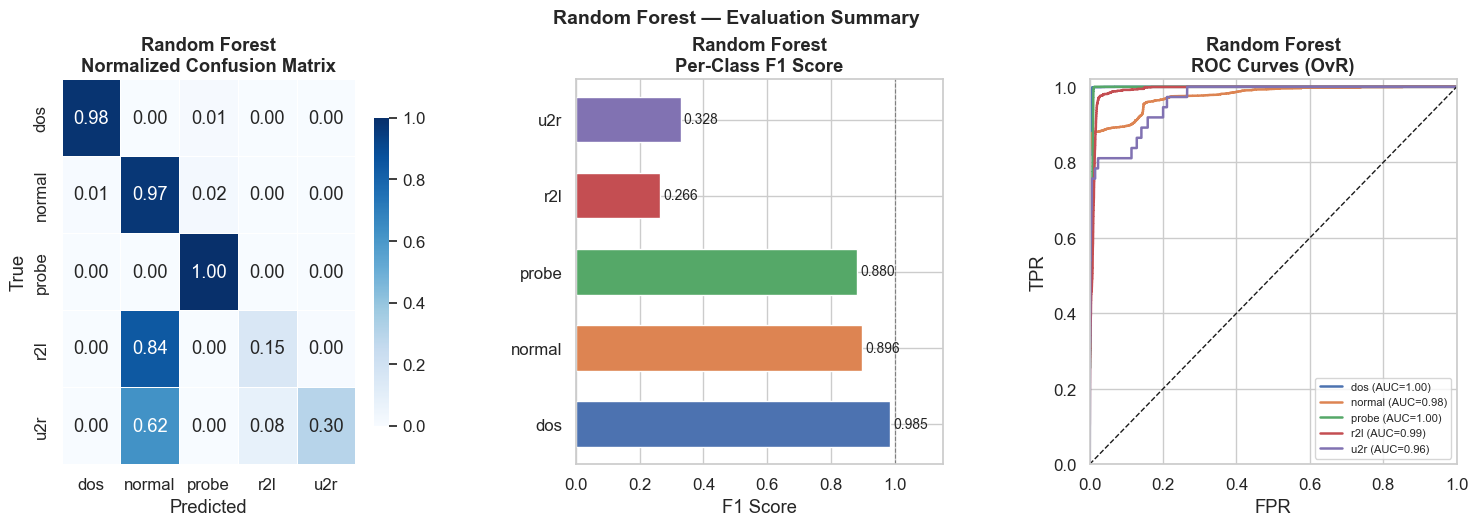

In [14]:
# ── Evaluate Random Forest ────────────────────────────────────────
y_pred_rf = rf_model.predict(X_test_sel)
y_prob_rf  = rf_model.predict_proba(X_test_sel)
rf_metrics = evaluate_model('Random Forest', y_test, y_pred_rf, y_prob_rf)


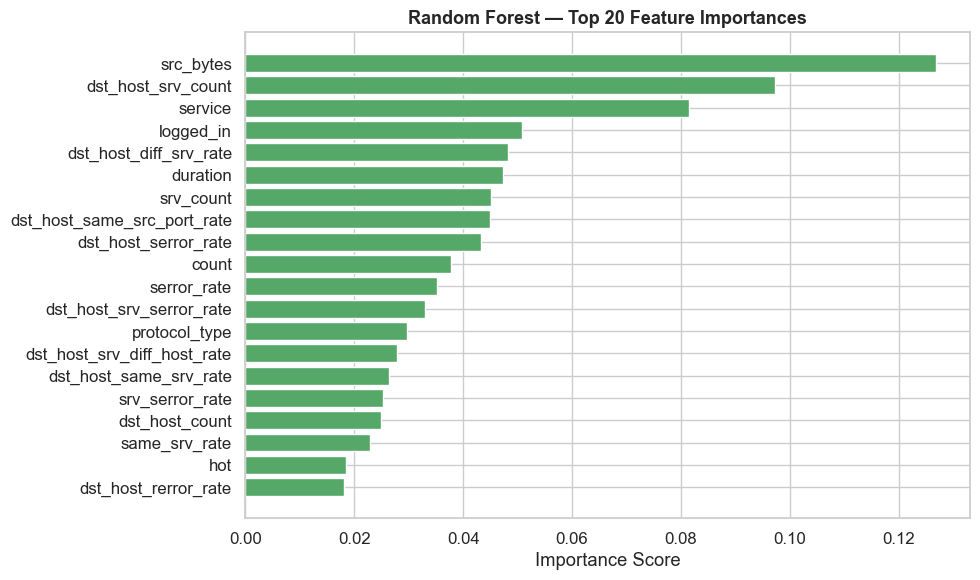

In [15]:
# ── Random Forest Feature Importance (Top 20) ─────────────────────
importances_rf = rf_model.feature_importances_
top_idx_rf     = np.argsort(importances_rf)[-20:]

fig, ax = plt.subplots(figsize=(10, 6))
feat_labels_rf = [selected_names[i] if i < len(selected_names) else f'F{i}' for i in top_idx_rf]
ax.barh(feat_labels_rf, importances_rf[top_idx_rf], color='#55A868', edgecolor='white')
ax.set_title('Random Forest — Top 20 Feature Importances', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'rf_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## Part 4 · Weighted Soft Voting Ensemble
Combines the predicted probabilities of all three models with weights:
**SVM × 1 + XGBoost × 2 + Random Forest × 2** (tree models trusted more as they train on full data).


In [16]:
# ── Weighted soft vote ────────────────────────────────────────────
prob_avg   = (y_prob_svm * 1 + y_prob_xgb * 2 + y_prob_rf * 2) / 5
y_pred_ens = np.argmax(prob_avg, axis=1)

print('Ensemble predictions computed.')
print(f'Unique predicted classes: {np.unique(y_pred_ens)}')


Ensemble predictions computed.
Unique predicted classes: [0 1 2 3 4]



  Weighted Soft Voting Ensemble
  Accuracy  : 0.8913
  Macro F1  : 0.7017
  Precision : 0.7951
  Recall    : 0.7047
-------------------------------------------------------
              precision    recall  f1-score   support

         dos       0.99      0.99      0.99      5741
      normal       0.85      0.97      0.90      9711
       probe       0.82      1.00      0.90      1106
         r2l       0.98      0.24      0.38      2199
         u2r       0.34      0.32      0.33        37

    accuracy                           0.89     18794
   macro avg       0.80      0.70      0.70     18794
weighted avg       0.90      0.89      0.87     18794



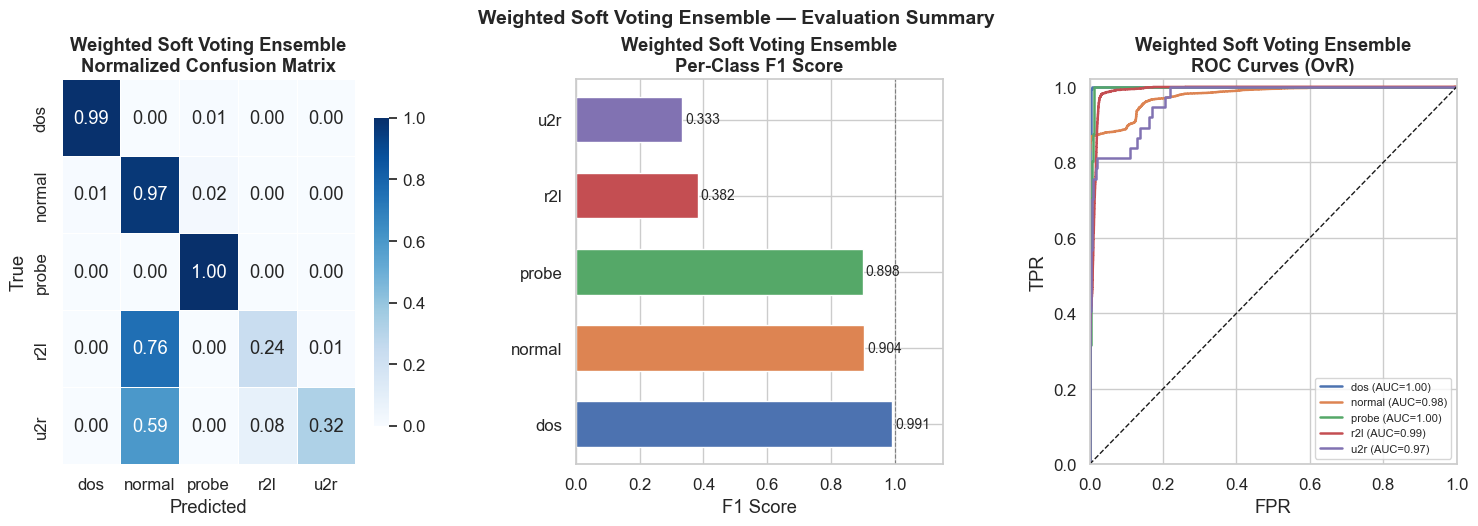

In [17]:
# ── Evaluate Ensemble ─────────────────────────────────────────────
ens_metrics = evaluate_model('Weighted Soft Voting Ensemble', y_test, y_pred_ens, prob_avg)


---
## Part 5 · Cross-Model Comparison


In [18]:
# ── Comparison table ─────────────────────────────────────────────
all_metrics = [svm_metrics, xgb_metrics, rf_metrics, ens_metrics]
df_compare  = pd.DataFrame(all_metrics).set_index('model').round(4)
print('\n' + '='*60)
print('  MODEL COMPARISON SUMMARY')
print('='*60)
print(df_compare.to_string())
print('='*60)
df_compare



  MODEL COMPARISON SUMMARY
                               accuracy  macro_f1  precision  recall
model                                                               
SVM (RBF)                        0.8660    0.6201     0.7243  0.6441
XGBoost                          0.8984    0.7093     0.7880  0.7075
Random Forest                    0.8785    0.6711     0.7895  0.6807
Weighted Soft Voting Ensemble    0.8913    0.7017     0.7951  0.7047


,accuracy,macro_f1,precision,recall
model,,,,
SVM (RBF),0.8660,0.6201,0.7243,0.6441
XGBoost,0.8984,0.7093,0.7880,0.7075
Random Forest,0.8785,0.6711,0.7895,0.6807
Weighted Soft Voting Ensemble,0.8913,0.7017,0.7951,0.7047


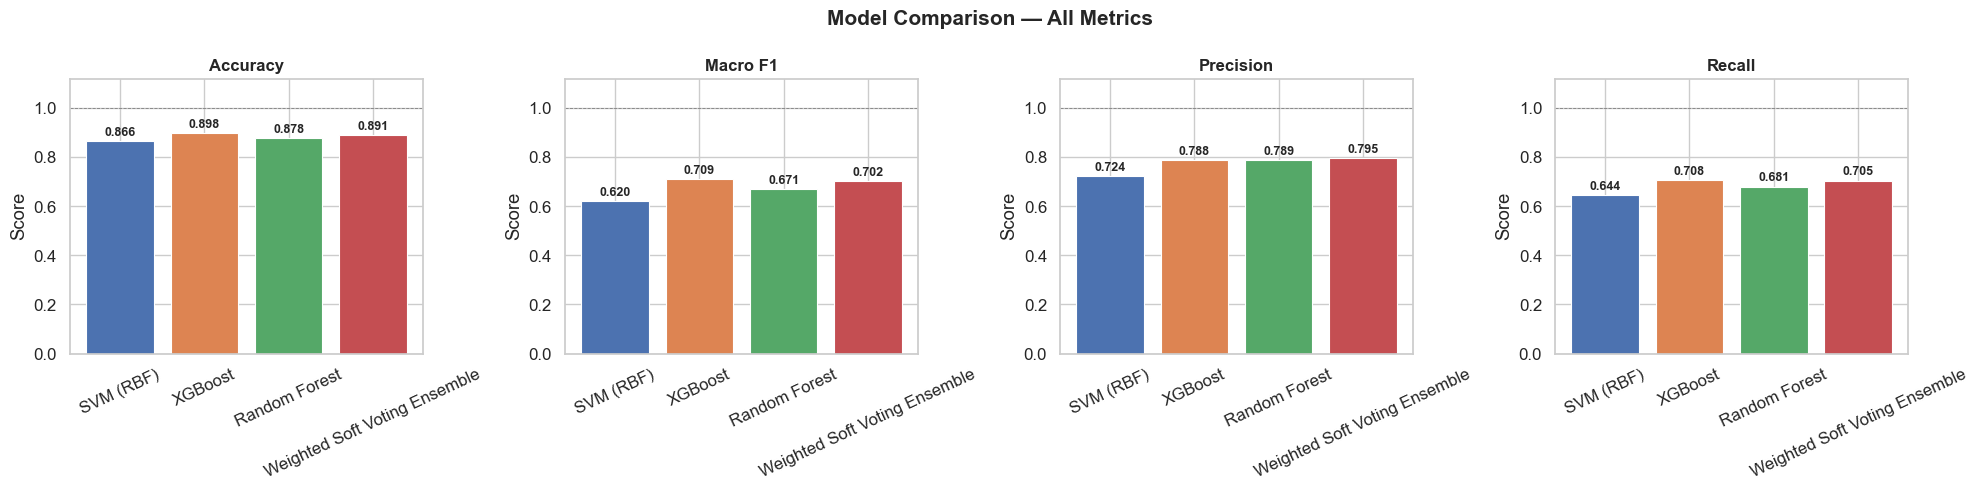

In [19]:
# ── Side-by-side bar charts (4 metrics) ──────────────────────────
bar_colors  = ['#4C72B0','#DD8452','#55A868','#C44E52']
metric_list = ['accuracy','macro_f1','precision','recall']
fig, axes   = plt.subplots(1, 4, figsize=(20, 5))

for ax, metric in zip(axes, metric_list):
    vals  = df_compare[metric].values
    names = df_compare.index.tolist()
    bars  = ax.bar(names, vals, color=bar_colors, edgecolor='white', linewidth=0.8)
    ax.set_ylim(0, 1.12)
    ax.set_title(metric.replace('_',' ').title(), fontweight='bold', fontsize=12)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=25)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.6)

plt.suptitle('Model Comparison — All Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'model_comparison_bars.png'), dpi=150, bbox_inches='tight')
plt.show()


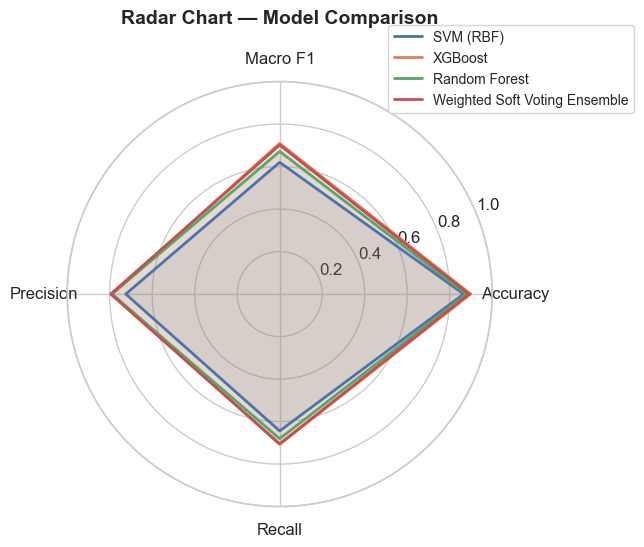

In [20]:
# ── Radar chart ───────────────────────────────────────────────────
radar_metrics = ['accuracy','macro_f1','precision','recall']
radar_labels  = ['Accuracy','Macro F1','Precision','Recall']
N = len(radar_metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})
for i, (model, color) in enumerate(zip(df_compare.index, bar_colors)):
    vals_r  = df_compare.loc[model, radar_metrics].tolist()
    vals_r += vals_r[:1]
    ax.plot(angles, vals_r, color=color, linewidth=2, label=model)
    ax.fill(angles, vals_r, color=color, alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2,0.4,0.6,0.8,1.0])
ax.set_title('Radar Chart — Model Comparison', fontweight='bold', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'model_radar_chart.png'), dpi=150, bbox_inches='tight')
plt.show()


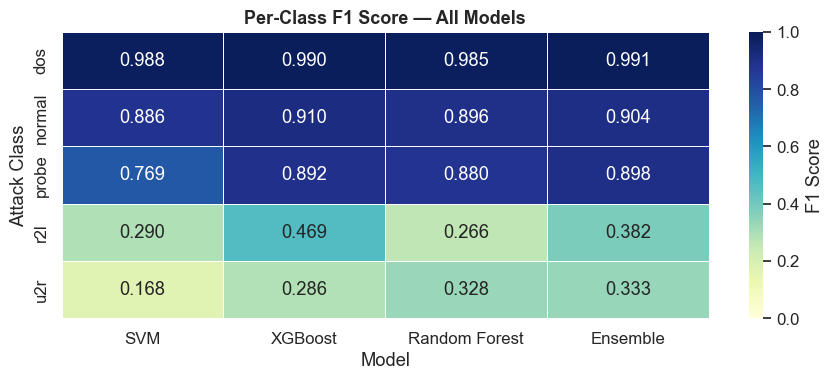

In [21]:
# ── Per-class F1 heatmap (all models) ────────────────────────────
f1_data = {}
preds   = [('SVM', y_pred_svm), ('XGBoost', y_pred_xgb),
           ('Random Forest', y_pred_rf), ('Ensemble', y_pred_ens)]
for name, yp in preds:
    rep = classification_report(y_test, yp, target_names=LABELS,
                                 output_dict=True, zero_division=0)
    f1_data[name] = [rep[l]['f1-score'] for l in LABELS]

df_f1 = pd.DataFrame(f1_data, index=LABELS)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(df_f1, annot=True, fmt='.3f', cmap='YlGnBu',
            linewidths=0.5, vmin=0, vmax=1, ax=ax,
            cbar_kws={'label':'F1 Score'})
ax.set_title('Per-Class F1 Score — All Models', fontweight='bold', fontsize=13)
ax.set_xlabel('Model'); ax.set_ylabel('Attack Class')
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'f1_heatmap_all_models.png'), dpi=150, bbox_inches='tight')
plt.show()


In [22]:
# ── Final summary print ───────────────────────────────────────────
winner = df_compare['macro_f1'].idxmax()
print('\n' + chr(9733)*55)
print('  FINAL MODEL SUMMARY')
print(chr(9733)*55)
print(f'\n  Best model by Macro F1  →  {winner}')
print(f'  Macro F1 Score          :  {df_compare.loc[winner, "macro_f1"]:.4f}')
print(f'  Accuracy                :  {df_compare.loc[winner, "accuracy"]:.4f}')
print('\n  All saved artifacts:')
for f in sorted(os.listdir(MODELS_DIR)):
    if f.endswith(('.pkl','.png')):
        print(f'    · {f}')
print(chr(9733)*55)



★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
  FINAL MODEL SUMMARY
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★

  Best model by Macro F1  →  XGBoost
  Macro F1 Score          :  0.7093
  Accuracy                :  0.8984

  All saved artifacts:
    · eda_class_dist.png
    · eda_protocol_heatmap.png
    · f1_heatmap_all_models.png
    · label_encoders.pkl
    · label_map.pkl
    · model_comparison_bars.png
    · model_radar_chart.png
    · random_forest_evaluation.png
    · rf_feature_importance.png
    · rf_model.pkl
    · scaler.pkl
    · selector.pkl
    · svm_model.pkl
    · svm_rbf_evaluation.png
    · weighted_soft_voting_ensemble_evaluation.png
    · xgb_feature_importance.png
    · xgb_model.pkl
    · xgboost_evaluation.png
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
